# WikiArt Style Classification - Test 4 (Improved Pipeline)

This notebook is a stronger experimental version of `test3`.

Main upgrades in this version:
- two-stage training (freeze backbone -> fine-tune all layers)
- stronger backbone (`ConvNeXt-Tiny`)
- class-weighted loss for imbalance
- stronger augmentation
- learning-rate scheduler + early stopping
- Top-1 and Top-5 accuracy tracking

## 1. Project Setup and Imports

We keep the setup readable and reproducible with fixed random seeds.

In [1]:
from pathlib import Path
import random
import warnings
import copy
import os
import numpy as np
import pandas as pd
from PIL import Image, UnidentifiedImageError

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

warnings.simplefilter("ignore", Image.DecompressionBombWarning)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Speed-friendly defaults on GPU
torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision("high")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## 2. Dataset Loading and Verification

This section reuses the working auto-discovery approach from the previous notebook.

In [2]:
def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "datasets").exists() and (candidate / "README.md").exists():
            return candidate
    return start.resolve()

def find_split_csv(data_dir: Path, split: str) -> Path:
    split = split.lower()
    csvs = sorted(data_dir.glob("*.csv"))
    if not csvs:
        raise FileNotFoundError(f"No CSV files found in {data_dir}")

    preferred = [p for p in csvs if split in p.stem.lower() and "style" in p.stem.lower()]
    if preferred:
        return preferred[0]

    fallback = [p for p in csvs if split in p.stem.lower()]
    if fallback:
        return fallback[0]

    raise FileNotFoundError(f"Could not find a '{split}' CSV in {data_dir}")

project_root = find_project_root(Path.cwd())
wikiart_dir = project_root / "datasets" / "Wikiart"

train_csv = find_split_csv(wikiart_dir, "train")
val_csv = find_split_csv(wikiart_dir, "val")

train_df = pd.read_csv(train_csv, header=None, names=["relative_path", "label"])
val_df = pd.read_csv(val_csv, header=None, names=["relative_path", "label"])

print(f"Project root: {project_root}")
print(f"WikiArt dir:  {wikiart_dir}")
print(f"Train CSV:    {train_csv.name}")
print(f"Val CSV:      {val_csv.name}")
print(f"Train rows:   {len(train_df):,}")
print(f"Val rows:     {len(val_df):,}")
display(train_df.head())

Project root: C:\Users\Thijs\Desktop\Ai Art Critic
WikiArt dir:  C:\Users\Thijs\Desktop\Ai Art Critic\datasets\Wikiart
Train CSV:    style_train.csv
Val CSV:      style_val.csv
Train rows:   57,025
Val rows:     24,421


,relative_path,label
0,Impressionism/edgar-degas_landscape-on-the-orn...,12
1,Realism/camille-corot_mantes-cathedral.jpg,21
2,Abstract_Expressionism/gene-davis_untitled-197...,0
3,Symbolism/kuzma-petrov-vodkin_in-the-1920.jpg,24
4,Impressionism/maurice-prendergast_paris-boulev...,12


In [3]:
def extract_style_name(relative_path: str) -> str:
    return Path(relative_path).parts[0]

train_df["style_name"] = train_df["relative_path"].map(extract_style_name)
val_df["style_name"] = val_df["relative_path"].map(extract_style_name)

label_to_style = (
    train_df[["label", "style_name"]]
    .drop_duplicates()
    .sort_values("label")
    .set_index("label")["style_name"]
    .to_dict()
)

num_classes = len(label_to_style)
print(f"Number of classes: {num_classes}")
print("First 10 mappings:")
for lbl, style in list(label_to_style.items())[:10]:
    print(f"{lbl:2d} -> {style}")

Number of classes: 27
First 10 mappings:
 0 -> Abstract_Expressionism
 1 -> Action_painting
 2 -> Analytical_Cubism
 3 -> Art_Nouveau_Modern
 4 -> Baroque
 5 -> Color_Field_Painting
 6 -> Contemporary_Realism
 7 -> Cubism
 8 -> Early_Renaissance
 9 -> Expressionism


## 3. Data Preprocessing and Augmentation

Training augmentations are stronger in this notebook:
- RandomResizedCrop (slight zoom/crop)
- RandomHorizontalFlip
- RandomRotation (+/-10)
- RandomAffine and RandomPerspective
- stronger ColorJitter
- RandomErasing

Validation/test transforms stay deterministic.

In [4]:
image_size = 256
batch_size = 16

# NOTE: In Windows notebooks, worker processes can add major overhead or appear to stall.
# Keep this conservative for stable throughput.
if device.type == "cuda":
    if os.name == "nt":
        num_workers = 0
    else:
        num_workers = min(8, max(2, (os.cpu_count() or 4) // 2))
else:
    num_workers = 0

pin_memory = device.type == "cuda"
persistent_workers = num_workers > 0
use_amp = device.type == "cuda"

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(image_size, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=12),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.85, 1.15)),
    transforms.RandomPerspective(distortion_scale=0.25, p=0.3),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.25, hue=0.03),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.2), ratio=(0.3, 3.3), value="random"),
])

eval_transform = transforms.Compose([
    transforms.Resize(int(image_size * 1.1)),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])

print(f"image_size={image_size}, batch_size={batch_size}, num_workers={num_workers}, pin_memory={pin_memory}, persistent_workers={persistent_workers}, use_amp={use_amp}")

image_size=256, batch_size=16, num_workers=0, pin_memory=True, persistent_workers=False, use_amp=True


## 4. Dataset and DataLoader Creation

We reuse the custom dataset approach and filter out missing/unreadable images before training.

In [5]:
class WikiArtStyleDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, image_root: Path, transform=None):
        self.df = dataframe.reset_index(drop=True).copy()
        self.image_root = Path(image_root)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = self.image_root / row["relative_path"]
        label = int(row["label"])

        image = Image.open(img_path).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)

        return image, label

In [6]:
import time

def filter_valid_rows(df: pd.DataFrame, image_root: Path, split_name: str, strict_verify: bool = False) -> pd.DataFrame:
    start = time.time()
    full_paths = df["relative_path"].map(lambda p: image_root / p)

    # Fast path: check path existence only (much faster for large datasets).
    exists_mask = full_paths.map(lambda p: p.exists())

    # Optional strict mode: verify only existing images (slower but more thorough).
    if strict_verify:
        valid_mask = exists_mask.copy()
        existing_indices = np.where(exists_mask.to_numpy())[0]
        total_existing = len(existing_indices)
        print(f"{split_name}: strict verification enabled for {total_existing:,} files...")
        for i, idx in enumerate(existing_indices, start=1):
            p = full_paths.iloc[idx]
            try:
                with Image.open(p) as im:
                    im.verify()
            except (UnidentifiedImageError, OSError, ValueError):
                valid_mask.iloc[idx] = False

            if i % 5000 == 0 or i == total_existing:
                print(f"{split_name}: verified {i:,}/{total_existing:,} files")
    else:
        valid_mask = exists_mask

    kept = int(valid_mask.sum())
    removed = int((~valid_mask).sum())
    took = time.time() - start
    print(f"{split_name}: kept {kept:,}, removed {removed:,} bad rows (took {took:.1f}s)")

    cleaned = df.loc[valid_mask].reset_index(drop=True)
    if cleaned.empty:
        raise RuntimeError(f"No valid rows left for split '{split_name}'.")
    return cleaned

# Use fast filtering by default to avoid long startup time.
STRICT_IMAGE_VERIFY = False
train_df_clean = filter_valid_rows(train_df, wikiart_dir, "train", strict_verify=STRICT_IMAGE_VERIFY)
val_df_clean = filter_valid_rows(val_df, wikiart_dir, "validation", strict_verify=STRICT_IMAGE_VERIFY)

CREATE_TEST_SPLIT = True
TEST_FRACTION_FROM_VAL = 0.15

if CREATE_TEST_SPLIT and len(val_df_clean) > 20:
    test_df = val_df_clean.sample(frac=TEST_FRACTION_FROM_VAL, random_state=SEED)
    val_eval_df = val_df_clean.drop(test_df.index).reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)
else:
    val_eval_df = val_df_clean
    test_df = None

train_dataset = WikiArtStyleDataset(train_df_clean, wikiart_dir, transform=train_transform)
val_dataset = WikiArtStyleDataset(val_eval_df, wikiart_dir, transform=eval_transform)
test_dataset = WikiArtStyleDataset(test_df, wikiart_dir, transform=eval_transform) if test_df is not None else None

loader_kwargs = {
    "num_workers": num_workers,
    "pin_memory": pin_memory,
    "persistent_workers": persistent_workers,
}

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, **loader_kwargs)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, **loader_kwargs)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, **loader_kwargs) if test_dataset is not None else None

print(f"Train samples: {len(train_dataset):,}")
print(f"Val samples:   {len(val_dataset):,}")
if test_dataset is not None:
    print(f"Test samples:  {len(test_dataset):,} (split from validation)")
else:
    print("Test set: not created")

train: kept 57,023, removed 2 bad rows (took 6.8s)
validation: kept 24,421, removed 0 bad rows (took 1.6s)
Train samples: 57,023
Val samples:   20,758
Test samples:  3,663 (split from validation)


## 5. Model Setup (Stronger Backbone)

Instead of ResNet50, we test a stronger architecture: **ConvNeXt-Tiny** with pretrained weights.

Its classifier layer is replaced to predict the number of WikiArt styles.

In [7]:
# Accuracy-first profile for final experiments.
# Set FAST_ITERATION_MODE=True only when you want quick sanity checks.
FAST_ITERATION_MODE = False

if FAST_ITERATION_MODE:
    MODEL_NAME = "resnet50"
    TOTAL_EPOCHS = 8
    HEAD_EPOCHS = 2
    MAX_TRAIN_BATCHES = 40
    MAX_VAL_BATCHES = 20
    HEAD_LR = 1e-3
    FT_LR = 3e-4
    WEIGHT_DECAY = 1e-4
    LABEL_SMOOTHING = 0.05
    MAX_GRAD_NORM = 1.0
else:
    MODEL_NAME = "convnext_tiny"
    TOTAL_EPOCHS = 36
    HEAD_EPOCHS = 5
    MAX_TRAIN_BATCHES = None
    MAX_VAL_BATCHES = None
    HEAD_LR = 7e-4
    FT_LR = 1.5e-4
    WEIGHT_DECAY = 5e-5
    LABEL_SMOOTHING = 0.1
    MAX_GRAD_NORM = 1.0

PATIENCE = 7
MIN_DELTA = 0.001

def build_model(model_name: str, num_classes: int):
    model_name = model_name.lower()

    if model_name == "convnext_tiny":
        weights = models.ConvNeXt_Tiny_Weights.DEFAULT
        model = models.convnext_tiny(weights=weights)
        in_features = model.classifier[2].in_features
        model.classifier[2] = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(in_features, num_classes),
        )
    elif model_name == "resnet50":
        weights = models.ResNet50_Weights.DEFAULT
        model = models.resnet50(weights=weights)
        in_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(in_features, num_classes),
        )
    else:
        raise ValueError("MODEL_NAME must be 'convnext_tiny' or 'resnet50'")

    return model

model = build_model(MODEL_NAME, num_classes).to(device)
print(f"Model: {MODEL_NAME}")
print(f"FAST_ITERATION_MODE={FAST_ITERATION_MODE}, TOTAL_EPOCHS={TOTAL_EPOCHS}, HEAD_EPOCHS={HEAD_EPOCHS}")
print(f"MAX_TRAIN_BATCHES={MAX_TRAIN_BATCHES}, MAX_VAL_BATCHES={MAX_VAL_BATCHES}")
print(f"HEAD_LR={HEAD_LR}, FT_LR={FT_LR}, WEIGHT_DECAY={WEIGHT_DECAY}, LABEL_SMOOTHING={LABEL_SMOOTHING}")

Model: convnext_tiny
FAST_ITERATION_MODE=False, TOTAL_EPOCHS=36, HEAD_EPOCHS=5
MAX_TRAIN_BATCHES=None, MAX_VAL_BATCHES=None
HEAD_LR=0.0007, FT_LR=0.00015, WEIGHT_DECAY=5e-05, LABEL_SMOOTHING=0.1


## 6. Training Improvements

This notebook applies several training improvements:
- **Two-stage training**: first train classifier head, then fine-tune full model
- **Class-weighted loss**: helps with class imbalance
- **Learning-rate scheduler** (`ReduceLROnPlateau`): lowers LR when validation loss stalls
- **Early stopping**: stops when validation Top-1 no longer improves

In [8]:
def get_classifier_parameters(model, model_name: str):
    if model_name == "convnext_tiny":
        return model.classifier.parameters()
    if model_name == "resnet50":
        return model.fc.parameters()
    raise ValueError("Unsupported model name")

def freeze_backbone(model, model_name: str):
    for p in model.parameters():
        p.requires_grad = False
    for p in get_classifier_parameters(model, model_name):
        p.requires_grad = True

def unfreeze_all(model):
    for p in model.parameters():
        p.requires_grad = True

def rand_bbox(size, lam):
    _, _, h, w = size
    cut_rat = np.sqrt(1.0 - lam)
    cut_w = int(w * cut_rat)
    cut_h = int(h * cut_rat)

    cx = np.random.randint(w)
    cy = np.random.randint(h)

    x1 = np.clip(cx - cut_w // 2, 0, w)
    x2 = np.clip(cx + cut_w // 2, 0, w)
    y1 = np.clip(cy - cut_h // 2, 0, h)
    y2 = np.clip(cy + cut_h // 2, 0, h)
    return x1, y1, x2, y2

# Strong regularization for better generalization
MIXUP_ALPHA = 0.3
CUTMIX_ALPHA = 0.8
MIX_STRATEGY_PROB = 0.7

# Class weights: inverse frequency, then normalized to mean 1.0
label_counts = train_df_clean["label"].value_counts().sort_index()
counts = np.array([label_counts.get(i, 1) for i in range(num_classes)], dtype=np.float32)
class_weights_np = counts.sum() / (num_classes * counts)
class_weights_np = class_weights_np / class_weights_np.mean()
class_weights = torch.tensor(class_weights_np, dtype=torch.float32, device=device)

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=LABEL_SMOOTHING)
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

# Stage 1: train only head
freeze_backbone(model, MODEL_NAME)
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=HEAD_LR,
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.999),
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.4, patience=3
)

print(f"Total epochs: {TOTAL_EPOCHS}")
print(f"Head epochs:  {HEAD_EPOCHS}")
print(f"Head LR:      {HEAD_LR}")
print(f"Fine-tune LR: {FT_LR}")
print(f"Weight decay: {WEIGHT_DECAY}")
print(f"Label smoothing: {LABEL_SMOOTHING}")
print(f"Max grad norm: {MAX_GRAD_NORM}")
print(f"Mixup alpha: {MIXUP_ALPHA}, CutMix alpha: {CUTMIX_ALPHA}, strategy_prob: {MIX_STRATEGY_PROB}")
print(f"Early stop patience: {PATIENCE}, min_delta: {MIN_DELTA}")

Total epochs: 36
Head epochs:  5
Head LR:      0.0007
Fine-tune LR: 0.00015
Weight decay: 5e-05
Label smoothing: 0.1
Max grad norm: 1.0
Early stop patience: 7, min_delta: 0.001


## 7. Training Loop

We track per-epoch metrics:
- train/validation loss
- train/validation Top-1 accuracy
- train/validation Top-5 accuracy

We also save the best checkpoint and restore it at the end.

In [9]:
def topk_accuracies(logits, targets, topk=(1, 5)):
    max_k = min(max(topk), logits.size(1))
    _, pred = logits.topk(max_k, dim=1, largest=True, sorted=True)
    pred = pred.t()
    correct = pred.eq(targets.view(1, -1).expand_as(pred))

    results = []
    for k in topk:
        kk = min(k, logits.size(1))
        correct_k = correct[:kk].reshape(-1).float().sum(0)
        results.append(correct_k.item() / targets.size(0))
    return results

def run_one_epoch(model, loader, criterion, optimizer=None, log_prefix="", print_every=20, max_batches=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    total_top1 = 0.0
    total_top5 = 0.0
    total_samples = 0

    num_batches = len(loader) if max_batches is None else min(len(loader), max_batches)
    epoch_start = time.time()

    for batch_idx, (images, labels) in enumerate(loader, start=1):
        if max_batches is not None and batch_idx > max_batches:
            break

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        labels_for_metrics = labels
        use_mixed_batch = (
            is_train and (MIXUP_ALPHA > 0 or CUTMIX_ALPHA > 0) and (np.random.rand() < MIX_STRATEGY_PROB)
        )

        with torch.set_grad_enabled(is_train):
            with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=use_amp):
                if use_mixed_batch:
                    index = torch.randperm(images.size(0), device=device)
                    y_a, y_b = labels, labels[index]

                    if CUTMIX_ALPHA > 0 and np.random.rand() < 0.5:
                        lam = np.random.beta(CUTMIX_ALPHA, CUTMIX_ALPHA)
                        x1, y1, x2, y2 = rand_bbox(images.size(), lam)
                        images_mixed = images.clone()
                        images_mixed[:, :, y1:y2, x1:x2] = images[index, :, y1:y2, x1:x2]
                        lam = 1.0 - ((x2 - x1) * (y2 - y1) / (images.size(-1) * images.size(-2)))
                    else:
                        lam = np.random.beta(MIXUP_ALPHA, MIXUP_ALPHA) if MIXUP_ALPHA > 0 else 1.0
                        images_mixed = lam * images + (1.0 - lam) * images[index]

                    outputs = model(images_mixed)
                    loss = lam * criterion(outputs, y_a) + (1.0 - lam) * criterion(outputs, y_b)
                else:
                    outputs = model(images)
                    loss = criterion(outputs, labels)

            if is_train:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                if MAX_GRAD_NORM is not None and MAX_GRAD_NORM > 0:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=MAX_GRAD_NORM)
                scaler.step(optimizer)
                scaler.update()

        batch_top1, batch_top5 = topk_accuracies(outputs, labels_for_metrics, topk=(1, 5))
        batch_size_now = labels.size(0)

        total_loss += loss.item() * batch_size_now
        total_top1 += batch_top1 * batch_size_now
        total_top5 += batch_top5 * batch_size_now
        total_samples += batch_size_now

        if batch_idx % print_every == 0 or batch_idx == num_batches:
            elapsed = time.time() - epoch_start
            avg_loss_so_far = total_loss / total_samples
            avg_top1_so_far = total_top1 / total_samples
            print(
                f"{log_prefix} batch {batch_idx:>4}/{num_batches} | "
                f"loss={avg_loss_so_far:.4f}, top1={avg_top1_so_far:.3f}, elapsed={elapsed/60:.1f}m"
            )

    avg_loss = total_loss / total_samples
    avg_top1 = total_top1 / total_samples
    avg_top5 = total_top5 / total_samples
    return avg_loss, avg_top1, avg_top5

history = []
best_val_top1 = -1.0
best_state = None
best_epoch = -1
epochs_no_improve = 0

checkpoint_path = project_root / "models" / "wikiart_test4_best.pt"
checkpoint_path.parent.mkdir(parents=True, exist_ok=True)

for epoch in range(1, TOTAL_EPOCHS + 1):
    # Switch to stage 2 at epoch HEAD_EPOCHS + 1
    if epoch == HEAD_EPOCHS + 1:
        unfreeze_all(model)
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=FT_LR,
            weight_decay=WEIGHT_DECAY,
            betas=(0.9, 0.999),
        )
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", factor=0.4, patience=3
        )

    stage = "head-only" if epoch <= HEAD_EPOCHS else "fine-tune"
    current_lr = optimizer.param_groups[0]["lr"]
    print(f"\nStarting epoch {epoch}/{TOTAL_EPOCHS} [{stage}]...")

    train_loss, train_top1, train_top5 = run_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer=optimizer,
        log_prefix=f"[train e{epoch}]",
        print_every=20,
        max_batches=MAX_TRAIN_BATCHES,
    )
    val_loss, val_top1, val_top5 = run_one_epoch(
        model,
        val_loader,
        criterion,
        optimizer=None,
        log_prefix=f"[val   e{epoch}]",
        print_every=20,
        max_batches=MAX_VAL_BATCHES,
    )

    scheduler.step(val_loss)

    history.append({
        "epoch": epoch,
        "stage": stage,
        "lr": current_lr,
        "train_loss": train_loss,
        "train_top1": train_top1,
        "train_top5": train_top5,
        "val_loss": val_loss,
        "val_top1": val_top1,
        "val_top5": val_top5,
    })

    improved = (val_top1 - best_val_top1) > MIN_DELTA
    if improved:
        best_val_top1 = val_top1
        best_state = copy.deepcopy(model.state_dict())
        best_epoch = epoch
        epochs_no_improve = 0
        torch.save(best_state, checkpoint_path)
    else:
        epochs_no_improve += 1

    print(
        f"Epoch {epoch:02d}/{TOTAL_EPOCHS} [{stage}] | lr={current_lr:.2e} | "
        f"train_loss={train_loss:.4f}, train_top1={train_top1:.3f}, train_top5={train_top5:.3f} | "
        f"val_loss={val_loss:.4f}, val_top1={val_top1:.3f}, val_top5={val_top5:.3f}"
    )

    if epochs_no_improve >= PATIENCE:
        print("Early stopping triggered.")
        break

if best_state is not None:
    model.load_state_dict(best_state)
    print(f"Restored best model from epoch {best_epoch} with val_top1={best_val_top1:.3f}")

history_df = pd.DataFrame(history)
display(history_df.tail(10))
print(f"Best checkpoint saved to: {checkpoint_path}")


Starting epoch 1/36 [head-only]...
[train e1] batch   20/3564 | loss=4.4805, top1=0.028, elapsed=0.2m
[train e1] batch   40/3564 | loss=4.6217, top1=0.023, elapsed=0.3m
[train e1] batch   60/3564 | loss=4.5582, top1=0.033, elapsed=0.5m
[train e1] batch   80/3564 | loss=4.4830, top1=0.045, elapsed=0.6m
[train e1] batch  100/3564 | loss=4.4340, top1=0.049, elapsed=0.7m
[train e1] batch  120/3564 | loss=4.3925, top1=0.053, elapsed=0.8m
[train e1] batch  140/3564 | loss=4.3590, top1=0.061, elapsed=0.9m
[train e1] batch  160/3564 | loss=4.3307, top1=0.072, elapsed=1.0m
[train e1] batch  180/3564 | loss=4.2898, top1=0.078, elapsed=1.1m
[train e1] batch  200/3564 | loss=4.2600, top1=0.083, elapsed=1.2m
[train e1] batch  220/3564 | loss=4.2491, top1=0.087, elapsed=1.3m
[train e1] batch  240/3564 | loss=4.2617, top1=0.094, elapsed=1.5m
[train e1] batch  260/3564 | loss=4.2428, top1=0.101, elapsed=1.6m
[train e1] batch  280/3564 | loss=4.2107, top1=0.106, elapsed=1.7m
[train e1] batch  300/3564

,epoch,stage,lr,train_loss,train_top1,train_top5,val_loss,val_top1,val_top5
22,23,fine-tune,0.000024,2.204865,0.911930,0.969504,4.549730,0.663648,0.765295
23,24,fine-tune,0.000024,2.196320,0.916998,0.970152,4.545967,0.663262,0.769294
24,25,fine-tune,0.000010,2.167670,0.929397,0.975308,4.561192,0.669043,0.766066
25,26,fine-tune,0.000010,2.164052,0.930870,0.976553,4.583338,0.664515,0.758744
26,27,fine-tune,0.000010,2.167064,0.933518,0.977185,4.595374,0.663070,0.757828
27,28,fine-tune,0.000010,2.161251,0.935324,0.978956,4.602094,0.664467,0.754986
28,29,fine-tune,0.000004,2.156864,0.940533,0.979920,4.593880,0.669525,0.756142
29,30,fine-tune,0.000004,2.157737,0.942620,0.979780,4.598681,0.668224,0.755612
30,31,fine-tune,0.000004,2.150564,0.943619,0.981078,4.594292,0.668851,0.754986
31,32,fine-tune,0.000004,2.151281,0.943795,0.980920,4.595536,0.669091,0.753107


Best checkpoint saved to: C:\Users\Thijs\Desktop\Ai Art Critic\models\wikiart_test4_best.pt


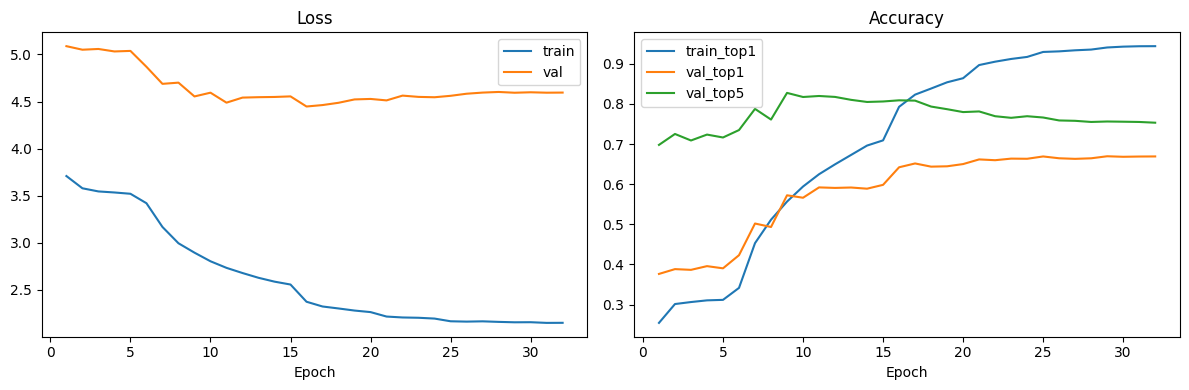

In [10]:
# Optional training curves (only if matplotlib is available)
try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None
    print("matplotlib is not installed in this environment. Skipping plots.")

if plt is not None and len(history_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train")
    axes[0].plot(history_df["epoch"], history_df["val_loss"], label="val")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(history_df["epoch"], history_df["train_top1"], label="train_top1")
    axes[1].plot(history_df["epoch"], history_df["val_top1"], label="val_top1")
    axes[1].plot(history_df["epoch"], history_df["val_top5"], label="val_top5")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

## 8. Final Evaluation

We report Top-1 and Top-5 on validation and on test split (if created).

In [11]:
def evaluate_model(model, loader, criterion):
    loss, top1, top5 = run_one_epoch(model, loader, criterion, optimizer=None)
    return {"loss": loss, "top1": top1, "top5": top5}

val_metrics = evaluate_model(model, val_loader, criterion)
print(
    f"Validation -> loss: {val_metrics['loss']:.4f}, "
    f"top1: {val_metrics['top1']:.3f}, top5: {val_metrics['top5']:.3f}"
)

if test_loader is not None:
    test_metrics = evaluate_model(model, test_loader, criterion)
    print(
        f"Test       -> loss: {test_metrics['loss']:.4f}, "
        f"top1: {test_metrics['top1']:.3f}, top5: {test_metrics['top5']:.3f}"
    )

 batch   20/1298 | loss=7.3158, top1=0.722, elapsed=0.1m
 batch   40/1298 | loss=7.3498, top1=0.719, elapsed=0.2m
 batch   60/1298 | loss=7.3550, top1=0.717, elapsed=0.3m
 batch   80/1298 | loss=7.3598, top1=0.720, elapsed=0.4m
 batch  100/1298 | loss=7.3503, top1=0.718, elapsed=0.5m
 batch  120/1298 | loss=7.3484, top1=0.719, elapsed=0.6m
 batch  140/1298 | loss=7.3468, top1=0.719, elapsed=0.6m
 batch  160/1298 | loss=7.3249, top1=0.725, elapsed=0.7m
 batch  180/1298 | loss=7.3119, top1=0.731, elapsed=0.8m
 batch  200/1298 | loss=7.3091, top1=0.732, elapsed=0.9m
 batch  220/1298 | loss=7.0703, top1=0.731, elapsed=1.0m
 batch  240/1298 | loss=6.7939, top1=0.727, elapsed=1.1m
 batch  260/1298 | loss=6.5463, top1=0.726, elapsed=1.2m
 batch  280/1298 | loss=6.3954, top1=0.720, elapsed=1.3m
 batch  300/1298 | loss=6.4169, top1=0.712, elapsed=1.4m
 batch  320/1298 | loss=6.4302, top1=0.708, elapsed=1.5m
 batch  340/1298 | loss=6.4492, top1=0.702, elapsed=1.6m
 batch  360/1298 | loss=6.4680,

## 9. Example Predictions

This reuses prediction logic from the reference notebook and prints several examples.

In [12]:
def predict_image_style(model, image_path: Path, transform, label_to_style_map, topk=5):
    model.eval()
    image = Image.open(image_path).convert("RGB")
    tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(tensor)
        probs = torch.softmax(logits, dim=1)
        top_probs, top_labels = probs.topk(k=min(topk, probs.shape[1]), dim=1)

    top_labels = top_labels[0].tolist()
    top_probs = top_probs[0].tolist()
    top_styles = [label_to_style_map.get(lbl, f"Unknown {lbl}") for lbl in top_labels]
    return top_labels[0], top_styles[0], list(zip(top_styles, top_probs))

source_df = test_df if test_df is not None and len(test_df) > 0 else val_eval_df
sample_df = source_df.sample(n=min(5, len(source_df)), random_state=SEED).reset_index(drop=True)

for i, row in sample_df.iterrows():
    sample_relative_path = row["relative_path"]
    true_label = int(row["label"])
    true_style = label_to_style.get(true_label, f"Unknown {true_label}")

    pred_label, pred_style, top5 = predict_image_style(
        model, wikiart_dir / sample_relative_path, eval_transform, label_to_style, topk=5
    )

    print(f"\nExample {i + 1}")
    print(f"Image path:       {sample_relative_path}")
    print(f"True style:       {true_style} ({true_label})")
    print(f"Predicted style:  {pred_style} ({pred_label})")
    print("Top-5 predictions:")
    for style_name, prob in top5:
        print(f"  - {style_name}: {prob:.3f}")


Example 1
Image path:       Minimalism/piero-manzoni_achrome-1960-2.jpg
True style:       Minimalism (14)
Predicted style:  Minimalism (14)
Top-5 predictions:
  - Minimalism: 0.814
  - Action_painting: 0.045
  - Analytical_Cubism: 0.042
  - Synthetic_Cubism: 0.021
  - New_Realism: 0.015

Example 2
Image path:       Realism/valentin-serov_winter-in-abramtsevo-1886-1.jpg
True style:       Realism (21)
Predicted style:  Impressionism (12)
Top-5 predictions:
  - Impressionism: 0.314
  - Action_painting: 0.170
  - Analytical_Cubism: 0.153
  - Synthetic_Cubism: 0.077
  - New_Realism: 0.053

Example 3
Image path:       Pop_Art/patrick-caulfield_cream-glazed-pot-1979.jpg
True style:       Pop_Art (19)
Predicted style:  Art_Nouveau_Modern (3)
Top-5 predictions:
  - Art_Nouveau_Modern: 0.581
  - Action_painting: 0.103
  - Analytical_Cubism: 0.094
  - Synthetic_Cubism: 0.047
  - New_Realism: 0.032

Example 4
Image path:       Impressionism/james-mcneill-whistler_rose-and-brown-la-cigale.jpg
True

## 10. Next Steps

To continue improving:
1. Try larger input size (for example 256) if GPU memory allows
2. Tune augmentation strength and batch size
3. Add label smoothing or mixup/cutmix
4. Export best model and integrate with your web app backend

This notebook is designed as a practical next step beyond the ~63% baseline while staying beginner-friendly.

In [13]:
# Quick summary of final training results
print("History rows:", len(history_df))
if len(history_df) > 0:
    print("\nBest validation Top-1 row:")
    best_idx = history_df["val_top1"].idxmax()
    display(history_df.loc[[best_idx]])

    print("\nLast 5 epochs:")
    display(history_df.tail(5))

print("\nFinal evaluation metrics:")
print("Validation:", val_metrics)
if "test_metrics" in globals():
    print("Test:", test_metrics)

print("\nBest checkpoint path:", checkpoint_path)
print("Best epoch:", best_epoch)
print("Best val_top1:", best_val_top1)

History rows: 32

Best validation Top-1 row:


,epoch,stage,lr,train_loss,train_top1,train_top5,val_loss,val_top1,val_top5
28,29,fine-tune,0.000004,2.156864,0.940533,0.97992,4.59388,0.669525,0.756142



Last 5 epochs:


,epoch,stage,lr,train_loss,train_top1,train_top5,val_loss,val_top1,val_top5
27,28,fine-tune,0.000010,2.161251,0.935324,0.978956,4.602094,0.664467,0.754986
28,29,fine-tune,0.000004,2.156864,0.940533,0.979920,4.593880,0.669525,0.756142
29,30,fine-tune,0.000004,2.157737,0.942620,0.979780,4.598681,0.668224,0.755612
30,31,fine-tune,0.000004,2.150564,0.943619,0.981078,4.594292,0.668851,0.754986
31,32,fine-tune,0.000004,2.151281,0.943795,0.980920,4.595536,0.669091,0.753107



Final evaluation metrics:
Validation: {'loss': 4.561191882916252, 'top1': 0.6690432604297138, 'top5': 0.7660660949995183}
Test: {'loss': 3.109938202645002, 'top1': 0.6541086541086542, 'top5': 0.7578487578487578}

Best checkpoint path: C:\Users\Thijs\Desktop\Ai Art Critic\models\wikiart_test4_best.pt
Best epoch: 25
Best val_top1: 0.6690432604297138


## 11. Save Results Registry (Tests 1-4)

This cell exports a consolidated metrics table for tests 1-4 so experiment results are persisted outside notebook outputs.

In [15]:
import json
import re
from datetime import datetime, timezone

def _collect_output_texts(cell):
    texts = []
    for out in cell.get("outputs", []):
        out_type = out.get("output_type")
        if out_type == "stream":
            t = out.get("text", "")
            if isinstance(t, list):
                t = "".join(t)
            texts.append(str(t))
        elif out_type in {"execute_result", "display_data"}:
            data = out.get("data", {})
            for key in ["text/plain", "text/markdown"]:
                if key in data:
                    t = data[key]
                    if isinstance(t, list):
                        t = "".join(t)
                    texts.append(str(t))
    return "\n".join(texts)

def _extract_last_float(text, pattern):
    matches = re.findall(pattern, text, flags=re.IGNORECASE)
    if not matches:
        return None
    return float(matches[-1])

def _extract_last_epoch_line_metrics(text):
    metrics = {"val_loss": None, "val_top1": None}
    epoch_matches = re.findall(
        r"Epoch\s+\d+/\d+\s*\|[^\n]*?val_loss\s*=\s*([0-9.]+)\s*,\s*val_acc\s*=\s*([0-9.]+)",
        text,
        flags=re.IGNORECASE,
    )
    if epoch_matches:
        val_loss, val_acc = epoch_matches[-1]
        metrics["val_loss"] = float(val_loss)
        metrics["val_top1"] = float(val_acc)
    return metrics

def _parse_metric_block(text):
    metrics = {
        "val_loss": None,
        "val_top1": None,
        "val_top5": None,
        "test_loss": None,
        "test_top1": None,
        "test_top5": None,
        "best_val_top1": None,
        "best_epoch": None,
    }

    # Test4-style outputs (loss + top1/top5)
    val_pat = re.search(
        r"Validation\s*->\s*loss:\s*([0-9.]+)\s*,\s*top1:\s*([0-9.]+)\s*,\s*top5:\s*([0-9.]+)",
        text,
        flags=re.IGNORECASE,
    )
    if val_pat:
        metrics["val_loss"] = float(val_pat.group(1))
        metrics["val_top1"] = float(val_pat.group(2))
        metrics["val_top5"] = float(val_pat.group(3))

    test_pat = re.search(
        r"Test\s*->\s*loss:\s*([0-9.]+)\s*,\s*top1:\s*([0-9.]+)\s*,\s*top5:\s*([0-9.]+)",
        text,
        flags=re.IGNORECASE,
    )
    if test_pat:
        metrics["test_loss"] = float(test_pat.group(1))
        metrics["test_top1"] = float(test_pat.group(2))
        metrics["test_top5"] = float(test_pat.group(3))

    # Test1-3 style outputs (accuracy-only lines)
    if metrics["val_top1"] is None:
        metrics["val_top1"] = _extract_last_float(
            text,
            r"(?:Best\s+validation\s+accuracy|Validation\s+accuracy|Final\s+validation\s+accuracy)\s*:\s*([0-9.]+)",
        )

    if metrics["test_top1"] is None:
        metrics["test_top1"] = _extract_last_float(
            text,
            r"(?:Test\s+accuracy\s*\(from\s+val\s+split\)|Simulated\s+test\s+accuracy|Final\s+test\s+accuracy)\s*:\s*([0-9.]+)",
        )

    # Pull val_loss from epoch logs when available
    if metrics["val_loss"] is None or metrics["val_top1"] is None:
        ep = _extract_last_epoch_line_metrics(text)
        if metrics["val_loss"] is None:
            metrics["val_loss"] = ep["val_loss"]
        if metrics["val_top1"] is None:
            metrics["val_top1"] = ep["val_top1"]

    metrics["best_val_top1"] = _extract_last_float(
        text,
        r"(?:Best\s+val_top1|Best\s+validation\s+accuracy)\s*:\s*([0-9.]+)",
    )
    metrics["best_epoch"] = _extract_last_float(text, r"Best\s+epoch\s*:\s*([0-9]+)")

    # If top5 missing in older tests, fall back to top1 as a placeholder for compatibility
    if metrics["val_top5"] is None and metrics["val_top1"] is not None:
        metrics["val_top5"] = metrics["val_top1"]
    if metrics["test_top5"] is None and metrics["test_top1"] is not None:
        metrics["test_top5"] = metrics["test_top1"]

    return metrics

def _extract_model_name(notebook_cells, text_blob):
    joined = "\n".join(
        "\n".join(c.get("source", []))
        for c in notebook_cells
        if c.get("cell_type") == "code"
    )
    m = re.search(r'MODEL_NAME\s*=\s*["\']([^"\']+)["\']', joined)
    if m:
        return m.group(1)

    # Fallback: infer from common backbone constructors
    for name in ["convnext_tiny", "resnet50", "resnet34", "resnet18"]:
        if re.search(name, joined, flags=re.IGNORECASE) or re.search(name, text_blob, flags=re.IGNORECASE):
            return name
    return None

def parse_notebook_metrics(nb_path: Path):
    if not nb_path.exists():
        return {
            "notebook": nb_path.name,
            "exists": False,
            "model_name": None,
            "val_loss": None,
            "val_top1": None,
            "val_top5": None,
            "test_loss": None,
            "test_top1": None,
            "test_top5": None,
            "best_val_top1": None,
            "best_epoch": None,
        }

    with nb_path.open("r", encoding="utf-8") as f:
        nb = json.load(f)

    cells = nb.get("cells", [])
    text_blob = "\n".join(_collect_output_texts(c) for c in cells if c.get("cell_type") == "code")
    parsed = _parse_metric_block(text_blob)

    return {
        "notebook": nb_path.name,
        "exists": True,
        "model_name": _extract_model_name(cells, text_blob),
        **parsed,
    }

rows = []
for i in range(1, 5):
    nb_path = project_root / f"wikiart_style_classification_test{i}.ipynb"
    row = parse_notebook_metrics(nb_path)
    row["experiment"] = f"test{i}"
    rows.append(row)

# Override test4 with live in-memory values when available (most reliable)
for row in rows:
    if row["experiment"] == "test4":
        row["model_name"] = MODEL_NAME if "MODEL_NAME" in globals() else row["model_name"]
        if "val_metrics" in globals():
            row["val_loss"] = float(val_metrics.get("loss", np.nan))
            row["val_top1"] = float(val_metrics.get("top1", np.nan))
            row["val_top5"] = float(val_metrics.get("top5", np.nan))
        if "test_metrics" in globals():
            row["test_loss"] = float(test_metrics.get("loss", np.nan))
            row["test_top1"] = float(test_metrics.get("top1", np.nan))
            row["test_top5"] = float(test_metrics.get("top5", np.nan))
        if "best_val_top1" in globals():
            row["best_val_top1"] = float(best_val_top1)
        if "best_epoch" in globals():
            row["best_epoch"] = int(best_epoch)

run_timestamp = datetime.now(timezone.utc).isoformat()
for row in rows:
    row["saved_at_utc"] = run_timestamp

results_df = pd.DataFrame(rows).sort_values("experiment").reset_index(drop=True)

results_dir = project_root / "models" / "results"
results_dir.mkdir(parents=True, exist_ok=True)

summary_csv = results_dir / "wikiart_tests_1_to_4_summary.csv"
summary_json = results_dir / "wikiart_tests_1_to_4_summary.json"
test4_history_csv = results_dir / "wikiart_test4_history.csv"

tmp_csv = summary_csv.with_suffix(".csv.tmp")
results_df.to_csv(tmp_csv, index=False)
os.replace(tmp_csv, summary_csv)

tmp_json = summary_json.with_suffix(".json.tmp")
with tmp_json.open("w", encoding="utf-8") as f:
    json.dump(results_df.to_dict(orient="records"), f, indent=2)
os.replace(tmp_json, summary_json)

if "history_df" in globals() and len(history_df) > 0:
    tmp_hist = test4_history_csv.with_suffix(".csv.tmp")
    history_df.to_csv(tmp_hist, index=False)
    os.replace(tmp_hist, test4_history_csv)

print("Saved consolidated results:")
print(f" - {summary_csv}")
print(f" - {summary_json}")
if "history_df" in globals() and len(history_df) > 0:
    print(f" - {test4_history_csv}")

display(results_df)

Saved consolidated results:
 - C:\Users\Thijs\Desktop\Ai Art Critic\models\results\wikiart_tests_1_to_4_summary.csv
 - C:\Users\Thijs\Desktop\Ai Art Critic\models\results\wikiart_tests_1_to_4_summary.json
 - C:\Users\Thijs\Desktop\Ai Art Critic\models\results\wikiart_test4_history.csv


,notebook,exists,model_name,val_loss,val_top1,val_top5,test_loss,test_top1,test_top5,best_val_top1,best_epoch,experiment,saved_at_utc
0,wikiart_style_classification_test1.ipynb,True,resnet18,1.438700,0.530000,0.530000,NaN,0.530000,0.530000,0.530000,NaN,test1,2026-03-11T20:40:53.839304+00:00
1,wikiart_style_classification_test2.ipynb,True,resnet18,1.254800,0.578000,0.578000,NaN,0.577000,0.577000,NaN,NaN,test2,2026-03-11T20:40:53.839304+00:00
2,wikiart_style_classification_test3.ipynb,True,resnet50,1.289900,0.632000,0.632000,NaN,0.632000,0.632000,NaN,NaN,test3,2026-03-11T20:40:53.839304+00:00
3,wikiart_style_classification_test4.ipynb,True,convnext_tiny,4.561192,0.669043,0.766066,3.109938,0.654109,0.757849,0.669043,25.0,test4,2026-03-11T20:40:53.839304+00:00
